Hands-On Lab: Activations & the Forward Pass:       
● Step 1: Plot ReLU, sigmoid, and tanh over a range of inputs to see how each transforms values.        
● Step 2: For the Phase 3 project task, decide the correct output activation and loss function, and justify both.           
● Step 3: By hand or in NumPy, compute one forward pass for a tiny 2-layer network on a sample input.       
● Step 4: Document the choices and the forward-pass result in Markdown.     

#### Load, Clean & split data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,recall_score, classification_report, confusion_matrix, f1_score

from sklearn.neural_network import MLPClassifier

In [2]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 1\Data\heart_disease.csv" )

In [3]:
print (df.shape,"\n")

print ("Null values: \n", df.isna().sum(),"\n")

print("duplicates :",df.duplicated().sum(),"\n")

(10000, 21) 

Null values: 
 Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64 

duplicates : 0 



In [4]:
print ("Information:")
df.info()

Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption 

In [5]:
print (df.columns)

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')


In [6]:
categorical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['str']).columns.tolist()

numerical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['int64','float64']).columns.tolist()

print("categorical columns name: ")
print(categorical_cols)

print("\nnumerical columns name: ")
print(numerical_cols)

categorical columns name: 
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

numerical columns name: 
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


we have some missing values so we deal with them:   

- numeric: fill with median.    
- categorical: fill with mode.    

for Alcohol Consumption we rectify the data since none is a category rather than a null value.

In [7]:
print("Alcohol Consumption categories Before: ", df['Alcohol Consumption'].unique())

# numnerical 
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# categorical
for col in categorical_cols: 
    
    if col == "Alcohol Consumption":
        df[col] = df[col].fillna("Zero")
        
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    
print ("\nAlcohol Consumption categories After: ", df['Alcohol Consumption'].unique())
print ("\nNull values 'after': \n", df.isna().sum(),"\n")


Alcohol Consumption categories Before:  <StringArray>
['High', 'Medium', 'Low', nan]
Length: 4, dtype: str

Alcohol Consumption categories After:  <StringArray>
['High', 'Medium', 'Low', 'Zero']
Length: 4, dtype: str

Null values 'after': 
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64 



In [8]:
X = df.drop(columns ='Heart Disease Status')
y = df['Heart Disease Status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify= y)

print(y_train.unique(),"\n")
print(y_train.value_counts(),"\n")
print(y_train.dtype)

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

Heart Disease Status
No     6400
Yes    1600
Name: count, dtype: int64 

str


### Nueral netwroks:

Heart Disease Status        
No / Yes

Output neurons:     1       
Output activation:  Sigmoid  , ReLU     
Loss function:      Binary Cross-Entropy        

##### Definitions: 


**Forward propagation:** data enters the network, passes through weighted connections and activation functions, and produces a prediction.

**Loss function:** measures how wrong that prediction is.

**Backpropagation:** calculates how much each weight contributed to the error. (output--> `gradiants`)

**Gradient descent / optimizer:** uses those `gradients` to update the weights so the model performs slightly better next time.

**Epochs and batches:** control how training data is repeatedly fed through the network.(max_iter=500)    

 - The model doesn't necessarily process all data at once, it can use batches, (batch_size = 32)-the number of samples-

 - One complete pass through all the samples is: 1 epoch, so (epochs=20) means the network sees the entire training dataset approximately 20 times.

**Learning rate:** controls how large each weight update is.



- The network's objective is essentially: **minimize loss**

##### Activation functions plots:

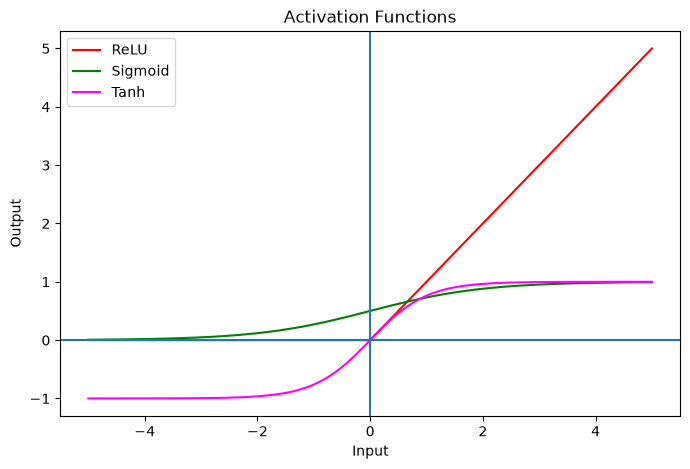

In [37]:
x = np.linspace(-5, 5, 200)

relu = np.maximum(0, x)

sigmoid = 1 / (1 + np.exp(-x))

tanh = np.tanh(x)

plt.figure(figsize=(8, 5))

plt.plot(x, relu, label="ReLU", color = 'red')
plt.plot(x, sigmoid, label="Sigmoid", color = 'green')
plt.plot(x, tanh, label="Tanh",color = 'magenta')

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Activation Functions")
plt.legend()

plt.show()

| Activation | Output                 | Main idea                                        |
| ---------- | ---------------------- | ------------------------------------------------ |
| ReLU       | (0 --> infinity) | Negative values become 0; positive values remain |
| Sigmoid    | (0 --> 1)      | Converts values to probability-like outputs      |
| tanh       | (-1 --> 1)     | Similar to sigmoid but centered around zero      |


##### One MANUAL forward pass for a tiny 2-layer network:

In [39]:
# 2 inputs
#    ↓
# 2 hidden neurons
#    ↓
# 1 output neuron


X_sample = np.array([1.0 , 2.0]) # input

# hidden layer
W1 = np.array([ [0.5 , -0.2],   
                [0.3 ,  0.8] 
              ])

b1 = np.array([0.1, -0.1]) # bias

# z1​= X W1 ​+ b1​
z1 = X_sample @ W1 + b1

# apply relu 
a1 = np.maximum(0, z1)


# output layer 
W2 = np.array([
    [0.7],
    [-0.4]
])

b2 = 0.2

z2 = a1 @ W2 + b2


# apply segmoid
output = 1 / (1 + np.exp(-z2))


print("Hidden layer before ReLU:", z1)
print("Hidden layer after ReLU:", a1)
print("Output before sigmoid:", z2)
print("Final output:", output)

Hidden layer before ReLU: [1.2 1.3]
Hidden layer after ReLU: [1.2 1.3]
Output before sigmoid: [0.52]
Final output: [0.62714777]


**Forward Pass**        
A small neural network containing two input features, two hidden neurons, and one output neuron was manually evaluated.     
 The hidden layer used ReLU activation and produced [1.2, 1.3].     
  The output layer produced a weighted value of 0.52.       
   After applying the sigmoid activation, the final network output was approximately 0.627.     
    Using a threshold of 0.5, this corresponds to the positive class.       

#### MLPClassifier:

In [ ]:
# scaling data is neccesary for nueral networks to give better results 

preprocessor = ColumnTransformer([("num",  StandardScaler(), numerical_cols)
                                 ,
                                ("col", OneHotEncoder(handle_unknown="ignore"),  categorical_cols)
                                 ])

**MLPClassifier** (Multi-layer Perceptron regressor)        
- Does the forward propagation, backpropagation, gradient calculation, and weight updates internally.


In [ ]:
nn_clf = MLPClassifier(  hidden_layer_sizes=(64,32),      # two hidden layers with first 64 neurons, second 32 neurons
                              activation='relu',          # 'relu' activation function
                              solver='adam',              # 'adam' solver for weight optimization
                              max_iter=300,               # Set the number of iterations (epochs)
                              random_state=42             # Set the seed for reproducibility
                            )

In [18]:
nn_pipe = Pipeline([ ("preprocessor", preprocessor)
                 ,
                     ("model", nn_clf )
                   ])

##### Normal fit predict:

In [20]:
nn_pipe.fit(X_train, y_train)

y_pred_nn = nn_pipe.predict(X_test)

c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [22]:
print("\nAccuracy:", accuracy_score(y_test, y_pred_nn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))


Accuracy: 0.682

Confusion Matrix:
[[1302  298]
 [ 338   62]]

Classification Report:
              precision    recall  f1-score   support

          No       0.79      0.81      0.80      1600
         Yes       0.17      0.15      0.16       400

    accuracy                           0.68      2000
   macro avg       0.48      0.48      0.48      2000
weighted avg       0.67      0.68      0.68      2000



##### Cross validation fit predict:

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True ,random_state=42)

nn_f1_scores = cross_val_score(nn_pipe, X_train,y_train, cv = cv, scoring="f1_macro",n_jobs=-1)

nn_acc_scores = cross_val_score(nn_pipe, X_train,y_train, cv = cv, scoring="accuracy",n_jobs=-1)


print(nn_f1_scores)
print("Mean CV F1:", nn_f1_scores.mean())
print("")
print(nn_acc_scores)
print("Mean CV accuracy:", nn_acc_scores.mean())


[0.49260782 0.51439983 0.51201851 0.50352731 0.50668067]
Mean CV F1: 0.50584682892672

[0.67375  0.688125 0.679375 0.68375  0.686875]
Mean CV accuracy: 0.682375


##### Training Loss:

 **`loss function`** :  measures how wrong the prediction was by comparing it to the true label

heart-disease project is binary classification therefore, the loss function: `binary cross-entropy` will be used. 

In [28]:
trained_mlp = nn_pipe.named_steps["model"]

print(trained_mlp.loss_curve_)

[np.float64(0.5317831573917591), np.float64(0.5015616706359639), np.float64(0.4982653794219345), np.float64(0.49616678336129927), np.float64(0.49408708427190273), np.float64(0.492463836101096), np.float64(0.4904374991291057), np.float64(0.48857674156445896), np.float64(0.48641658734597115), np.float64(0.4844680602792348), np.float64(0.48286763349163875), np.float64(0.4799267909464016), np.float64(0.47819357785851097), np.float64(0.4756338560522147), np.float64(0.47288772236674265), np.float64(0.47051587738599415), np.float64(0.4679941735202872), np.float64(0.4651741873156874), np.float64(0.4629095981286228), np.float64(0.45940461658326187), np.float64(0.4559493258830863), np.float64(0.45387908375566327), np.float64(0.45053947054478233), np.float64(0.44790729458299944), np.float64(0.44397127558034866), np.float64(0.4411177650571512), np.float64(0.4390271200951425), np.float64(0.43550343864521845), np.float64(0.4317888450799367), np.float64(0.4291245904474757), np.float64(0.4261414352480

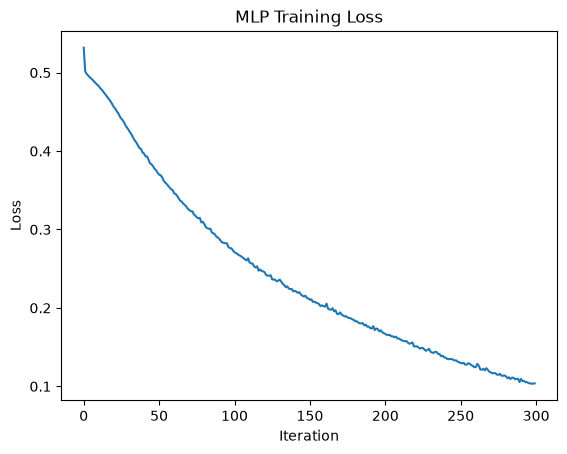

In [29]:
plt.plot(trained_mlp.loss_curve_)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.show()